In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150


df = pd.read_pickle('../data/processed/superstore_eda_ready.pkl')

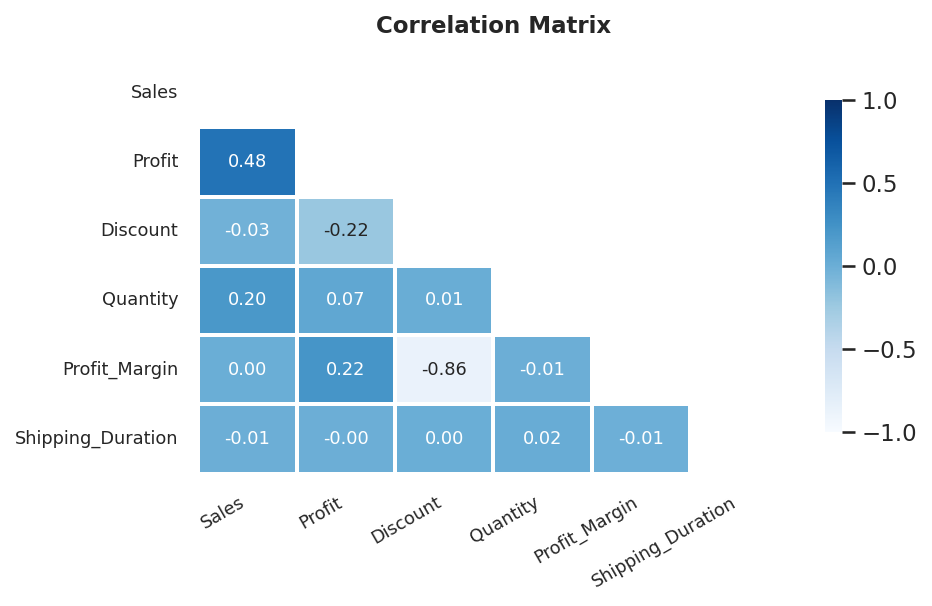

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['Sales', 'Profit', 'Discount', 'Quantity', 'Profit_Margin', 'Shipping_Duration']
corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(6.5, 4.2))

with sns.axes_style("white"):
    sns.heatmap(corr, mask=mask, annot=True, cmap='Blues', fmt='.2f', 
                vmin=-1, vmax=1, cbar_kws={'shrink': 0.8},
                annot_kws={"size": 8.5}, linewidths=1, linecolor='white')

plt.title('Correlation Matrix', fontsize=11, fontweight='bold', pad=12)
plt.xticks(fontsize=8.5, rotation=30, ha='right')
plt.yticks(fontsize=8.5)
plt.tight_layout()
plt.show()

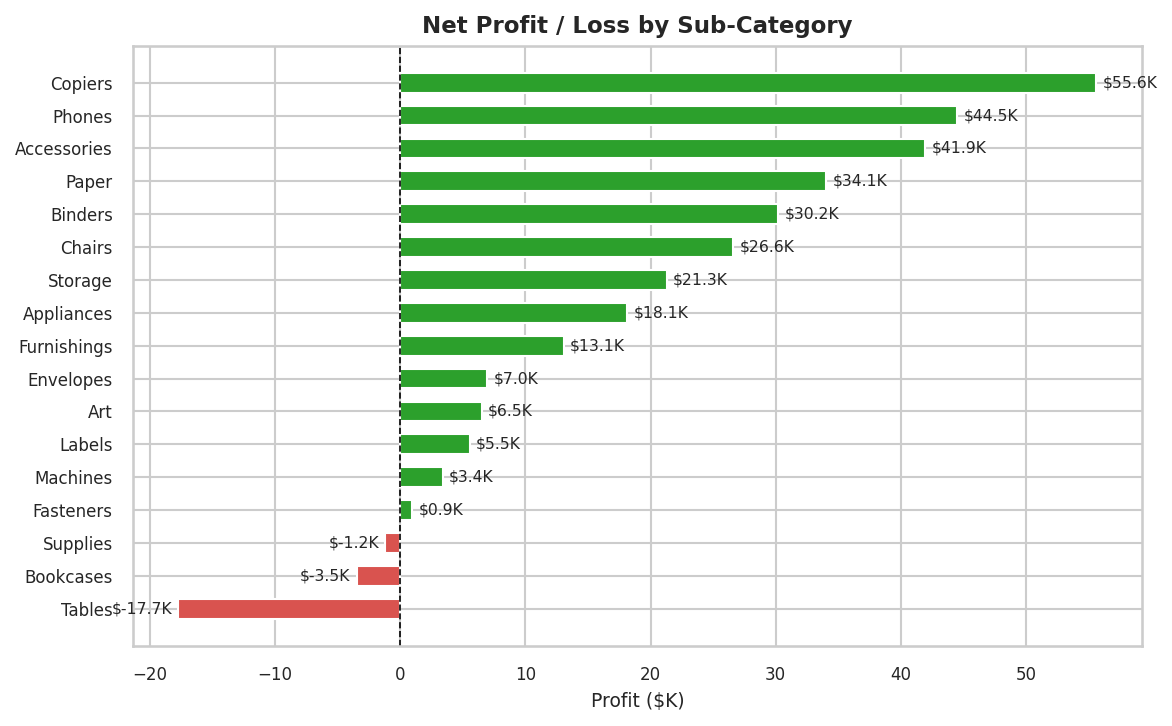

In [12]:
subcat_profit = df.groupby('Sub-Category',observed=False)['Profit'].sum().sort_values()

colors = ['#d9534f' if p < 0 else '#2ca02c' for p in subcat_profit]

plt.figure(figsize=(8, 5))
bars = plt.barh(subcat_profit.index, subcat_profit / 1e3, color=colors, height=0.6)


plt.bar_label(bars, fmt='$%.1fK', padding=3, fontsize=7.5)

plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Net Profit / Loss by Sub-Category', fontsize=11, fontweight='bold')
plt.xlabel('Profit ($K)', fontsize=9)
plt.yticks(fontsize=8)
plt.xticks(fontsize=8)
plt.tight_layout()
plt.show()

C:\Users\Abdullah\AppData\Local\Temp\ipykernel_10448\1551540896.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat = df.groupby('Category')[['Sales', 'Profit']].sum()


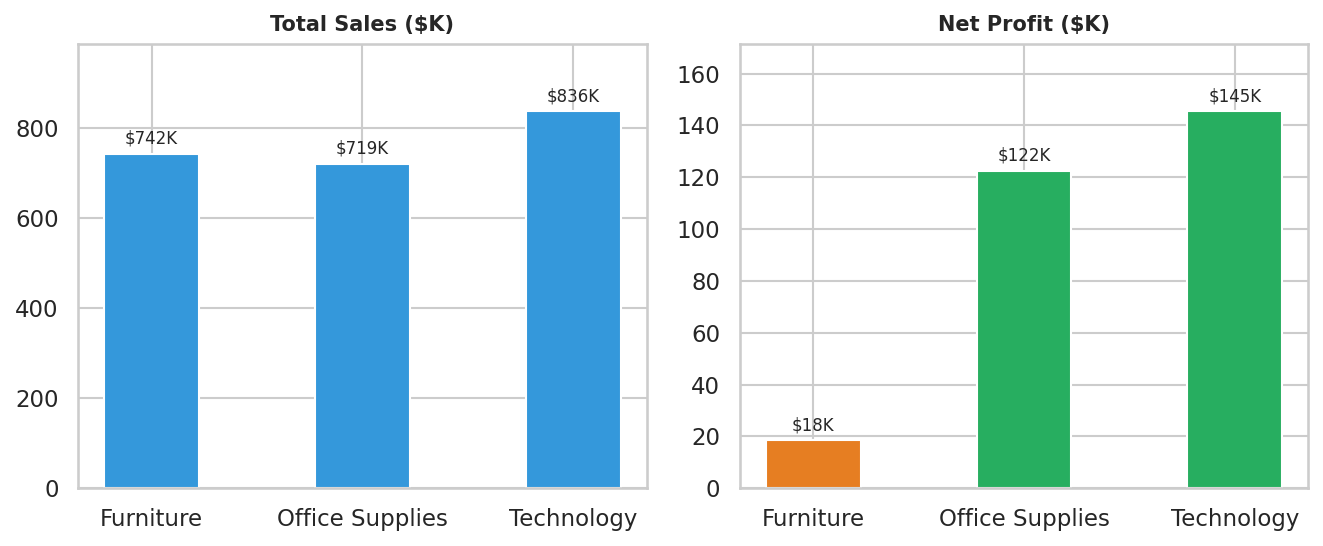

In [ ]:
cat = df.groupby('Category', observed=False)[['Sales', 'Profit']].sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.8))

# 1. Sales
bars1 = ax1.bar(cat.index, cat['Sales'] / 1e3, color='#3498db', width=0.45)
ax1.bar_label(bars1, fmt='$%.0fK', padding=3, fontsize=8)
ax1.set_title('Total Sales ($K)', fontsize=10, fontweight='bold')
ax1.set_ylim(0, (cat['Sales'].max() / 1e3) * 1.18)

# 2. Profit
colors = ['#e67e22' if c == 'Furniture' else '#27ae60' for c in cat.index]
bars2 = ax2.bar(cat.index, cat['Profit'] / 1e3, color=colors, width=0.45)
ax2.bar_label(bars2, fmt='$%.0fK', padding=3, fontsize=8)
ax2.set_title('Net Profit ($K)', fontsize=10, fontweight='bold')
ax2.set_ylim(0, (cat['Profit'].max() / 1e3) * 1.18)

plt.tight_layout()
plt.show()

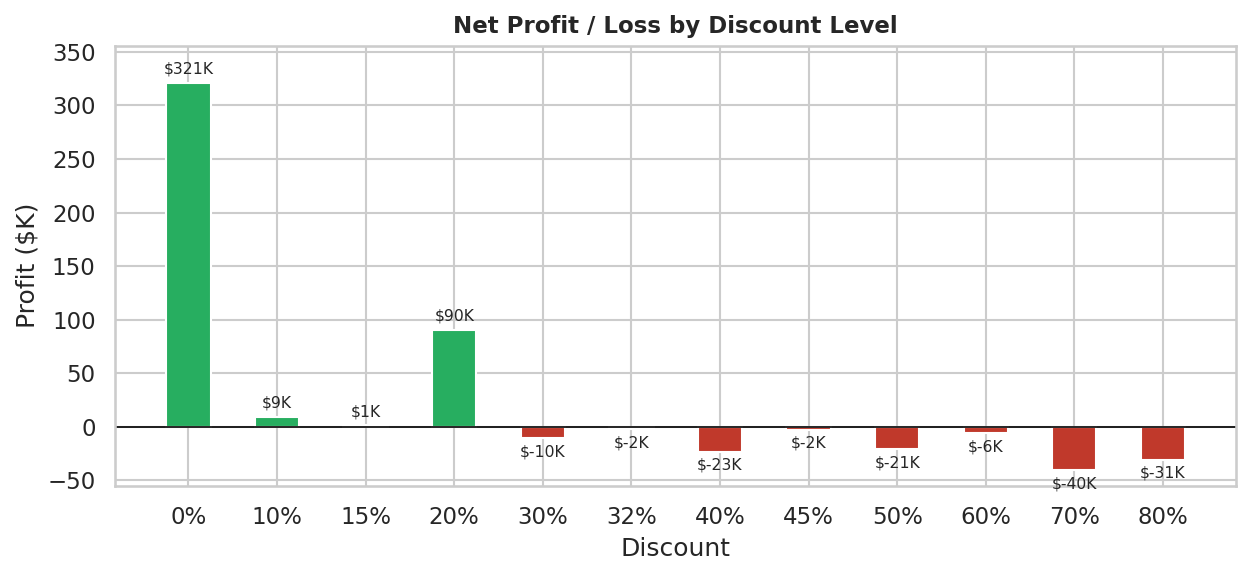

In [5]:
discount_profit = df.groupby('Discount')['Profit'].sum()

colors = ['#27ae60' if p >= 0 else '#c0392b' for p in discount_profit]
labels = [f"{int(d*100)}%" for d in discount_profit.index]

plt.figure(figsize=(8.5, 4))
bars = plt.bar(labels, discount_profit / 1e3, color=colors, width=0.5)

plt.axhline(0, color='black', linewidth=0.8)

plt.bar_label(bars, fmt='$%.0fK', padding=3, fontsize=7.5)

plt.title('Net Profit / Loss by Discount Level', fontsize=11, fontweight='bold')
plt.xlabel('Discount')
plt.ylabel('Profit ($K)')
plt.ylim((discount_profit.min() / 1e3) - 15, (discount_profit.max() / 1e3) + 35)
plt.tight_layout()
plt.show()

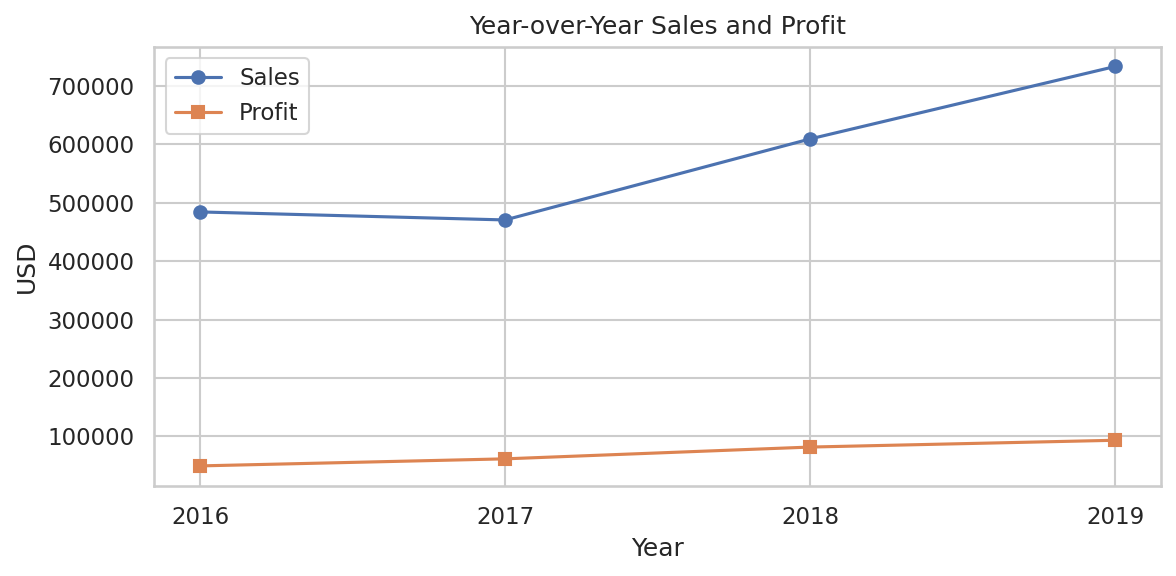

In [6]:
yearly = df.groupby('Order_Year')[['Sales', 'Profit']].sum()

plt.figure(figsize=(8, 4))
plt.plot(yearly.index, yearly['Sales'], marker='o', label='Sales')
plt.plot(yearly.index, yearly['Profit'], marker='s', label='Profit')

plt.title('Year-over-Year Sales and Profit')
plt.xlabel('Year')
plt.ylabel('USD')
plt.xticks(yearly.index)
plt.legend()
plt.tight_layout()
plt.show()


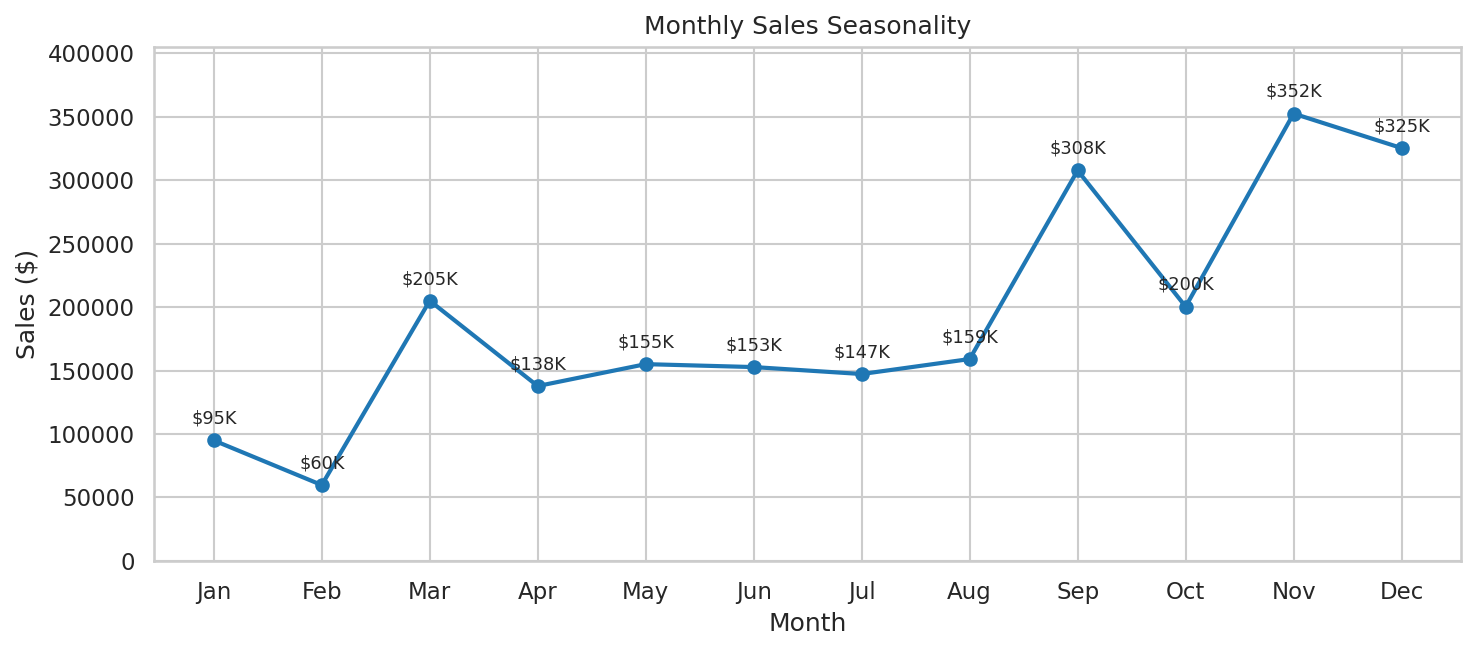

In [7]:
monthly = df.groupby('Order_Month')['Sales'].sum()

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(10, 4.5))
plt.plot(monthly.index, monthly.values, marker='o', color='#1f77b4', linewidth=2)

plt.title('Monthly Sales Seasonality')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(ticks=range(1, 13), labels=months)

for x, y in zip(monthly.index, monthly.values):
    plt.annotate(f"${y/1e3:.0f}K", (x, y), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8.5)

plt.ylim(0, monthly.max() * 1.15)
plt.tight_layout()
plt.show()

C:\Users\Abdullah\AppData\Local\Temp\ipykernel_10448\1957050218.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_rate = (df.groupby('Ship Mode')['Is_Delayed'].mean() * 100).sort_values(ascending=False)


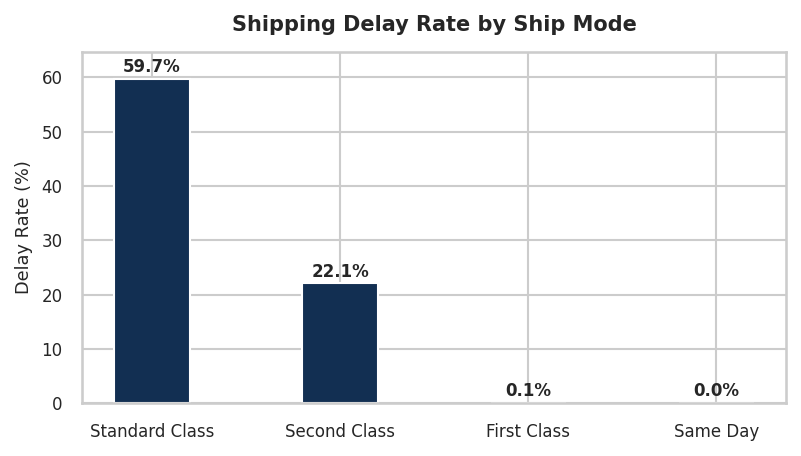

In [ ]:
delay_rate = (df.groupby('Ship Mode', observed=False)['Is_Delayed'].mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(5.5, 3.2))
bars = plt.bar(delay_rate.index, delay_rate.values, color="#122f52", width=0.4)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.1f}%", 
             ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.title('Shipping Delay Rate by Ship Mode', fontsize=10, fontweight='bold', pad=10)
plt.ylabel('Delay Rate (%)', fontsize=8.5)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.ylim(0, delay_rate.max() + 5)
plt.tight_layout()
plt.show()

C:\Users\Abdullah\AppData\Local\Temp\ipykernel_10448\2817364037.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment = df.groupby('Segment')[['Sales', 'Profit']].sum()


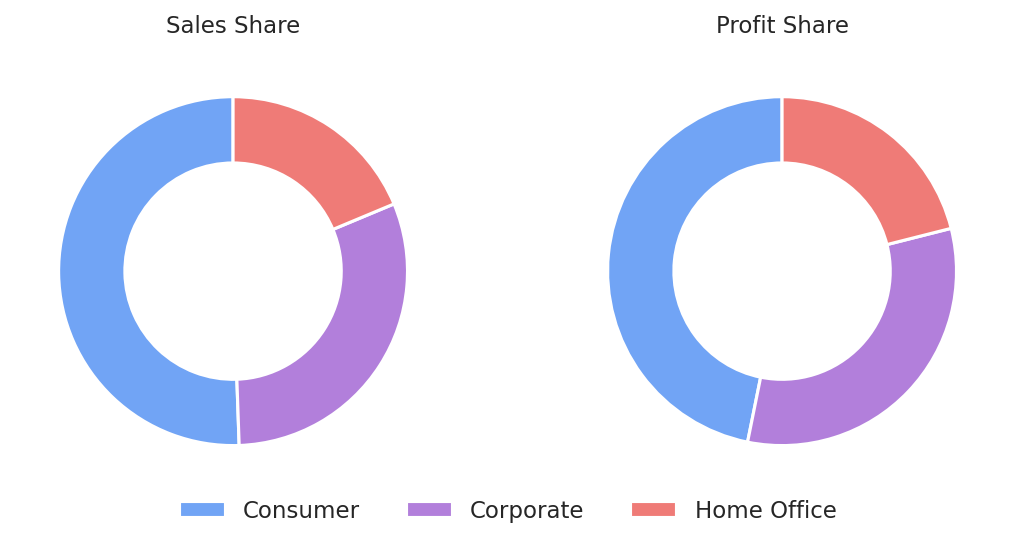

In [ ]:
segment = df.groupby('Segment', observed=False)[['Sales', 'Profit']].sum()

colors = ["#71A4F5", "#B27FDB", "#EF7B77"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 3.5))

# 1. Sales Donut
wedges1, _ = ax1.pie(segment['Sales'], colors=colors, startangle=90, 
                     wedgeprops=dict(width=0.38, edgecolor='white', linewidth=1.5))
ax1.set_title('Sales Share', fontsize=11, pad=10)

# 2. Profit Donut
wedges2, _ = ax2.pie(segment['Profit'], colors=colors, startangle=90, 
                     wedgeprops=dict(width=0.38, edgecolor='white', linewidth=1.5))
ax2.set_title('Profit Share', fontsize=11, pad=10)

fig.legend(wedges1, segment.index, loc="lower center", 
           bbox_to_anchor=(0.5, -0.05), ncol=3, frameon=False)

plt.tight_layout()
plt.show()

C:\Users\Abdullah\AppData\Local\Temp\ipykernel_10448\2721332995.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_vip = df.groupby('Customer Name')['Sales'].sum().nlargest(10).sort_values()


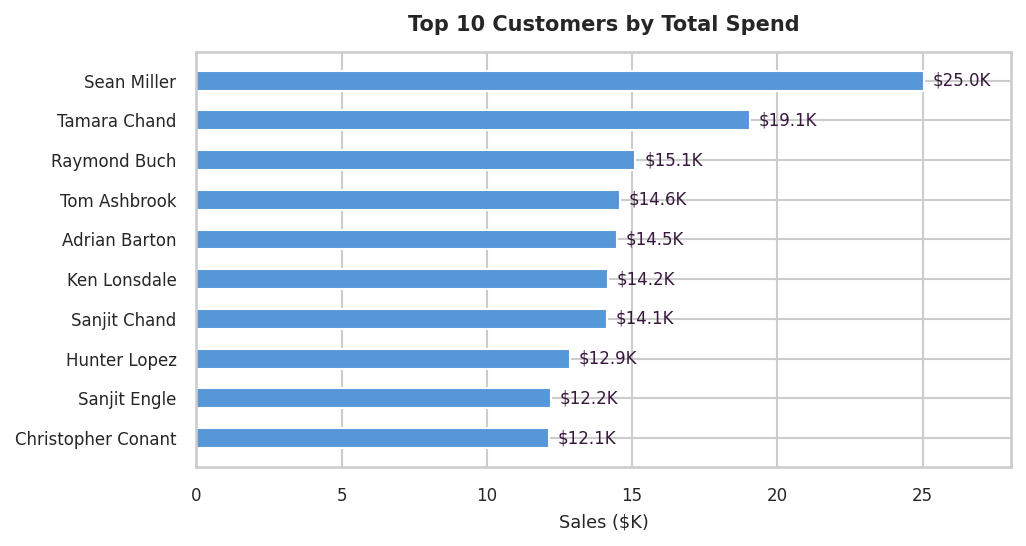

In [ ]:
top_vip = df.groupby('Customer Name', observed=False)['Sales'].sum().nlargest(10).sort_values()

plt.figure(figsize=(7, 3.8))
bars = plt.barh(top_vip.index, top_vip.values / 1e3, color="#5697d7", height=0.5)

for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.3, bar.get_y() + bar.get_height()/2, f"${w:.1f}K", 
             va='center', fontsize=8, color="#37173c")

plt.title('Top 10 Customers by Total Spend', fontsize=10, fontweight='bold', pad=10)
plt.xlabel('Sales ($K)', fontsize=8.5)
plt.yticks(fontsize=8)  
plt.xticks(fontsize=8)
plt.xlim(0, (top_vip.max() / 1e3) + 3)
plt.tight_layout()
plt.show()

In [11]:
def kpi_summary(df):
    sales = df['Sales'].sum()
    profit = df['Profit'].sum()
    margin = (profit / sales) * 100
    delay = df['Is_Delayed'].mean() * 100

    print(f"Total Sales  : ${sales:,.0f}")
    print(f"Total Profit : ${profit:,.0f}")
    print(f"Profit Margin: {margin:.1f}%")
    print(f"Delay Rate   : {delay:.1f}%")

kpi_summary(df)

Total Sales  : $2,297,201
Total Profit : $286,397
Profit Margin: 12.5%
Delay Rate   : 40.0%


# Executive Summary & Strategic Recommendations

## Executive Summary & Recommendations

### Key Insights
* **The Discount Issue:** Discounts above **20%** cause severe profit losses. Discounts do not increase order volume (Correlation ≈ **0.00**), but strongly hurt margins (**-0.86**).
* **Unprofitable Products:** `Tables` and `Bookcases` are generating consistent net losses despite high sales volume.
* **Q4 Peak:** Highest revenue and profit occur during **Q4 (Nov & Dec)**.
* **Core Segment:** The `Consumer` segment drives ~**50%** of total business revenue and profit.

---

### Strategic Actions
1. **Cap Discounts:** Set a maximum discount limit of **15% - 20%**.
2. **Fix Loss-Makers:** Increase prices or renegotiate supplier costs for `Tables` and `Bookcases`.
3. **Prepare for Q4:** Stock up inventory ahead of the November–December sales rush.
4. **Improve Delivery:** Resolve fulfillment delays in `Same Day` and `First Class` shipping.